## 다중 퍼셉트론(MLP)

In [2]:
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/전처리완료.csv")

In [4]:
# 데이터 분리 라이브러리
from sklearn.model_selection import train_test_split

# 특징 변수(X)와 목표 변수(y) 분리
X = df.drop('고객이탈여부', axis=1)
y = df['고객이탈여부']

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(10,)))  # 10개의 입력 특성
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # 이진 분류의 경우

In [6]:
# 모델 컴파일
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 모델 훈련
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# 모델 평가
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_accuracy:.4f}')

Epoch 1/10
200/200 [==============================] - 1s 1ms/step - loss: 0.0000e+00 - accuracy: 0.7777 - val_loss: 0.0000e+00 - val_accuracy: 0.7987
Epoch 2/10
200/200 [==============================] - 0s 714us/step - loss: 0.0000e+00 - accuracy: 0.7934 - val_loss: 0.0000e+00 - val_accuracy: 0.7987
Epoch 3/10
200/200 [==============================] - 0s 715us/step - loss: 0.0000e+00 - accuracy: 0.7934 - val_loss: 0.0000e+00 - val_accuracy: 0.7987
Epoch 4/10
200/200 [==============================] - 0s 725us/step - loss: 0.0000e+00 - accuracy: 0.7934 - val_loss: 0.0000e+00 - val_accuracy: 0.7987
Epoch 5/10
200/200 [==============================] - 0s 749us/step - loss: 0.0000e+00 - accuracy: 0.7934 - val_loss: 0.0000e+00 - val_accuracy: 0.7987
Epoch 6/10
200/200 [==============================] - 0s 744us/step - loss: 0.0000e+00 - accuracy: 0.7934 - val_loss: 0.0000e+00 - val_accuracy: 0.7987
Epoch 7/10
200/200 [==============================] - 0s 719us/step - loss: 0.0000e+00 - a

63/63 [==============================] - 0s 418us/step


array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [15]:
# 성과평가 라이브러리 불러오기
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score
# 예측값 생성
y_pred_proba = model.predict(X_test)  # 예측 확률값
y_pred = (y_pred_proba > 0.5).astype(int)  # 0.5를 기준으로 이진 분류

# 평가
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall", recall_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))



63/63 [==============================] - 0s 643us/step
Accuracy: 0.8035
Precision: 0.0
Recall 0.0
f1_score 0.0
Confusion Matrix:
 [[1607    0]
 [ 393    0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89      1607
           1       0.00      0.00      0.00       393

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.80      0.72      2000



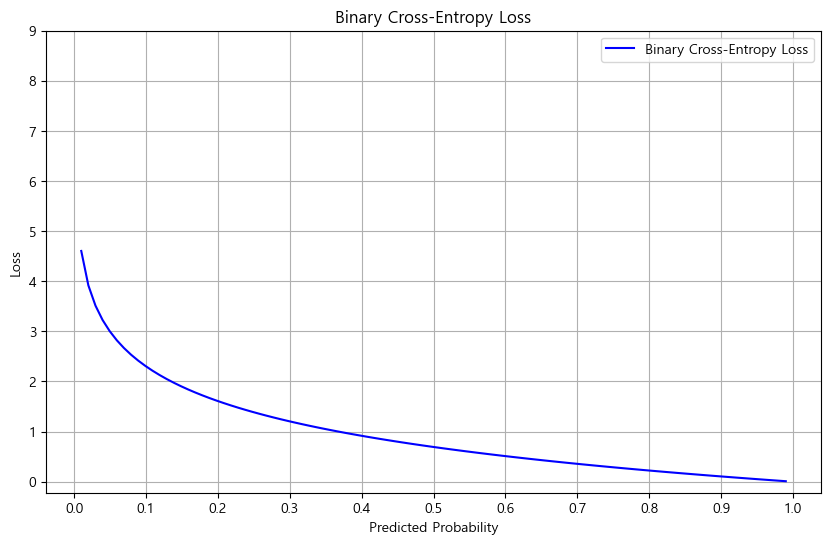

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 이진 크로스 엔트로피 함수 정의
def binary_cross_entropy(y_true, y_pred):
    return - (y_true * np.log(y_pred + 1e-10) + (1 - y_true) * np.log(1 - y_pred + 1e-10))

# 예측 확률과 실제 값 설정
y_true = 1  # 실제 클래스
y_pred = np.linspace(0.01, 0.99, 100)  # 0.01부터 0.99까지의 예측 확률

# 손실 계산
loss = binary_cross_entropy(y_true, y_pred)

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(y_pred, loss, label='Binary Cross-Entropy Loss', color='blue')
plt.title('Binary Cross-Entropy Loss')
plt.xlabel('Predicted Probability')
plt.ylabel('Loss')
plt.xticks(np.arange(0, 1.1, 0.1))
plt.yticks(np.arange(0, 10, 1))
plt.grid()
plt.legend()
plt.show()


### MLP 모델 만들기


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense

# 랜덤 데이터 생성
np.random.seed(42)
X = np.random.rand(1000, 1)  # 1000개의 샘플, 1개의 특성
y = 3 * X.squeeze() + np.random.normal(0, 0.1, 1000)  # y = 3x + 노이즈

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:
# ANN 모델 생성
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))  # 입력층
model.add(Dense(32, activation='relu'))  # 은닉층
model.add(Dense(1))  # 출력층 (회귀 문제이므로 활성화 함수 없음)

# 모델 컴파일
model.compile(optimizer='adam', loss='mean_squared_error')

# 모델 훈련
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# 예측
y_pred = model.predict(X_test)

# 결과 시각화
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred, color='red', label='Predicted')
plt.title('Actual vs Predicted')
plt.xlabel('Input Feature')
plt.ylabel('Target Variable')
plt.legend()
plt.show()